<h1>Muistiinpanot 09: Klusetrointi & k-means algoritmi</h1>
<i>Niko Mehiläinen 18.09.2026</i> <br/>
Lähde: https://github.com/vesavvo/dkko/blob/211661c6bc980ee2ef852c2947cde88be65a45fc/Clustering_and_kmeans.ipynb

- Ei ennustettavaa
- "Onko näistä havainnoista lähellä toisiaan, jotka muodostavat luonteenomaisen ryhmän?"
- "Onko ryhmien välillä selvä poikkeama?"
- Käytetään: <b>Kohdennettu markkinointi</b>, <b>tuotevalikoimien pohtiminen</b>

<h2>Hierarkinen klusterointi (Kokeeseen)</h2>

- <i>TODELLA RASKAS KOULUTTAA.</i> $O( N^3 )$
    - Jos data on pieni ei ole ongelma.
- Kaikki havainnot alunperin omassa klusterissaan

1. Lasketaan kaikkien euclidinen etäisyys ja etsitään kaksi lähintä havaintoa.
       <br/>- Ensimmäinen kahden pisteen klusteri on luotu, ne ovat nyt yksi klusteri
2. Lasketaan uudet eclidisten etäisyydet ja etsitään uusi lähin etäisyys

<center><b>HUOM! Kun klusteri muodostuu tai uusi havainto lisätään klusteriin; niiden keskipiste on piste mihin lasketaan etäisyys!</b></center>



<h3>Mikä on hyvä klusteri?</h3>

- Voidaan tarkistaa, siten että tarkistetaan jokaisen havainnon etäisyys oman klusterin keskipisteestä.
- <b>WCSS</b> = within cluster sum of squares
    - asd
- Mitä vähemmän klustereita sitä parempi.
- " <i>Elbow method</i> "
- Alkutilanne $\frac{N * (N - 1)}{2}$

<h2>k-means algoritmi</h2>

- Suosituin klusterointi algoritmi.
- <b>Vaikea selittää O notaatiolla! ~</b>
    - $k*N$
    - $O((k*N) * (N_{iteraatioiden määrä})$
- k on <b>hyperparametri</b> (täytyy kovakoodata)
    - testaamalla löytyy k

<h3>k-means vaiheet ( Mahdollinen koekysymys (ei tarvitse laskea euclidista etäisyyttä) )</h3>

1. Alustetaan k klusterikeskipisteitä.
   - Arvotaan satunnaisesti k määrä havaintoja, jotka valitaan klusterin keskipisteeksi.
   - Tämä satunnaisuus alustusvaiheessa voi vaikuttaa klusterin optimaalisuuteen.
       - Jos käy todella huonotuuri voi tulla huonoja klustereita.
2. Liitetään jokainen havainto siihen klusteriin, jonka keskipistettä ne ovat lähimpänä.
3. Päivitetään klusterikeskipisteiden sijainnit muodostuneen klusterijaon mukaisesti.
4. Päivitetään vaiheita 2 & 3 niin kauan, että klusterikeskipiste ei enään muutu.


<h3>Kuinka lasketaan klusterin keskipiste? ( ISOSTI KOKEESEEN 100% )</h3> (2.4, 1,7)

- Arvot ovat xy -akselilla.
- Laske x & y kordinaattien keskiarvo


!!!
En tiedä mitä laskin, pitää korjata...
4 -> p: $1^2 + 1,5^2$ = 3,25 <br/>
4 -> 5: $1,6^2 + 0,2^2$ = 2,6  (SINISEEN)

6 -> p: $2,6^2 + 1,3^2$ <br/>
6 -> 5: $1-1$
!!!

<h2>Iris esimerkki</h2>
Lähtökohta: Annetaa datafreimille vain selittävät ominaisuudet ja katsotaan ryhmittyävätkö eri kasvit oikeisiin klustereihin.

**huom. sklearn (k = n_clusters)**

In [141]:
import os
# Estetään Windowsin MKL-muistivuotovaroitus
os.environ["OMP_NUM_THREADS"] = "1"

from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

In [143]:
from sklearn.cluster import KMeans

# Asetetaan n_init eksplisiittisesti (esim. n_init=10 tai n_init='auto')
model = KMeans(n_clusters=3, init="random", n_init=10, random_state=42)
model.fit(X)

C:\Users\nikom\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(init='random', n_clusters=3, n_init=10, random_state=42)

In [144]:
labels = model.labels_
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2,
       2, 2, 2, 1, 1, 2, 2, 2, 2, 1, 2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

In [145]:
print('Class setosa:', labels[:50])
print('\nClass versicolor:', labels[50:100])
print('\nClass virginica:', labels[100:])

Class setosa: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]

Class versicolor: [1 1 2 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1]

Class virginica: [2 1 2 2 2 2 1 2 2 2 2 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 1 2 2 2 2 2 1 2 2 2
 2 1 2 2 2 1 2 2 2 1 2 2 1]


In [146]:
#esim. asiakkaiden kulutustottumuksia ja voidaan tutkia erinnäisiä piirteitä.
model.cluster_centers_ 

array([[5.006     , 3.428     , 1.462     , 0.246     ],
       [5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [151]:
model.predict(X[-10:])

array([2, 2, 1, 2, 2, 2, 1, 2, 2, 1])

C:\Users\nikom\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\nikom\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\nikom\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\nikom\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are

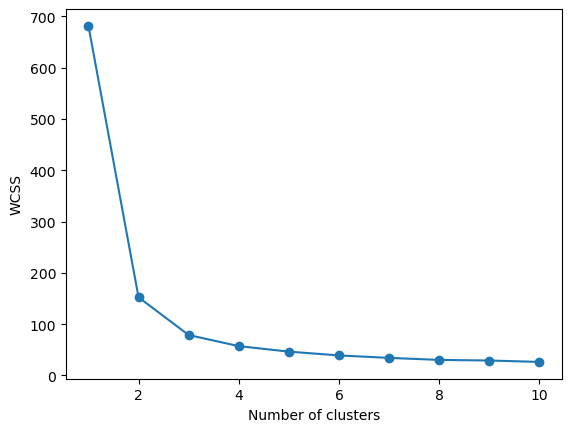

In [152]:
#ELBOW METHOD -> OPTIMAL COULD BE ~3

import matplotlib.pyplot as plt

wcss = []
for i in range(1,11):
    model = KMeans(init='random', n_clusters=i, random_state=42).fit(X)
    wcss.append(model.inertia_)
    
plt.plot(range(1,11), wcss, 'o-')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.show()

In [157]:
# hyvä vastine wcss luvulle.
# lasketaan jokaiselle havainolle ja keskiarvoistetaan koko dataseitille
# A: lasketaan kaikkiin samassa kluserilla oleviin havainto
# B: Samasta havainnosta naapuriklusteriin
# hyväklusteri b >> a, "b olisi jumalattoman paljon isompi kuin a"
# jos b ja a saman suuruisia siluetti +-0, heikko klusteri ("ei hyödyllinen").
# jos siluetti negatiivinen -> naapuri lähempänä -> HUONO KLUSTERI!!
# 1 on aika hyvetti! <3
# 0.55 "aika ok, ei mikään tähtitieteellinen saavutus, mutta pontentiaalisesti hyödyllinen"

from sklearn.metrics import silhouette_score

model = KMeans(init='random', n_clusters=3, random_state=42).fit(X)
labels = model.labels_
print('Silhouette score = %.2f' % silhouette_score(X, labels))

C:\Users\nikom\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
C:\Users\nikom\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


Silhouette score = 0.55


---

<b>!!! Viikkotehtävä huomautuksia:</b>
 - viikkotehtävissä ei ole esimerkkiä hierarkisesta klusteroinissa.
    - klusterit poikkeavat visuaalisesti toisistaan. <b>kmeans != hierarkinen klusetrointi</b>
 - Etsi kolme kappaletta droonisijainteja datasta, jotta palvelee asiakkaita parhaiten.
 - "Teette suoraan ohjeistuksen mukaisesti"
 - "Värikoodaa"
 - csv #1 -> klusterointi
 - csv #2 -> assosiioita